# Space-Time Modeling of Regional Unemployment (PROC REG)


## Executive Summary

This notebook fits a **space-time autoregression** to the monthly unemployment rates of four contiguous western states -- California, Oregon, Washington, and Nevada -- using **`PROC REG`**. A STAR(1;1) model predicts each state's change in unemployment from two forces: its own change last month, and the average change among the states it borders, encoded in a spatial weight map. The whole model needs just **two coefficients** -- an own-lag term and a spatial term -- however many locations you track.

We assemble the four series, first-difference them to stationarity, stack the states into one pooled panel, and fit the two coefficients by ordinary least squares through the origin. Test `71070` cross-validates the same fit against an independent R implementation.

## Data Sources

| Source | Frequency | Span | Description |
|--------|-----------|------|-------------|
| `state_ur_levels.csv` (FRED snapshot: `CAUR`, `ORUR`, `WAUR`, `NVUR`) | Monthly | 1990-01 to 2024-12 | State unemployment rate (%) for CA, OR, WA, NV |

The four series are a committed snapshot of Federal Reserve FRED data (series `CAUR`, `ORUR`, `WAUR`, `NVUR`), so the notebook runs offline and reproducibly. The companion docs guide shows the live `SASEFRED` pull that produced this snapshot.

## Why a Space-Time Model

Regional labor markets are not islands. A plant closing in one state ripples into the states next door as commuters, suppliers, and demand shift across the border. A **space-time autoregression** captures two channels at once:

- **Temporal persistence** -- how strongly a state follows its own recent path.
- **Spatial spillover** -- how strongly a state follows its neighbors' recent path.

Written out, the STAR(1;1) model for location $i$ at time $t$ is

$$ y_{i,t} = \phi_{10}\, y_{i,t-1} + \phi_{11}\, (W y)_{i,t-1} + \varepsilon_{i,t}, $$

where $W$ is the **spatial weight map**: row $i$ names state $i$'s neighbors and splits a weight of 1 evenly among them, so $(Wy)_{i,t-1}$ is just the average change across $i$'s neighbors last month. Stacked over states the model is a vector autoregression with coefficient matrix $\Phi = \phi_{10} I + \phi_{11} W$ -- two scalars and a fixed map in place of a full, free coefficient matrix.

## Step 1 -- Assemble the four state series

Start by loading the four monthly unemployment-rate series into one wide table keyed on `date`.

In [1]:
/* Load a committed snapshot of four contiguous western   states' monthly unemployment rate (FRED: CAUR, ORUR,   WAUR, NVUR), 1990-2024. The docs guide shows the live   SASEFRED pull that produced this file. */data levels;    set "state_ur_levels.csv";run;


NOTE: DATA levels


NOTE: Read 420 rows from state_ur_levels.csv.
NOTE: Wrote levels (420 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.30 seconds
  cpu   0.30 seconds


## Step 2 -- Difference to stationarity

Unemployment rates drift over the business cycle, so a level-on-level model would mostly rediscover the trend. First-differencing each series leaves the month-to-month **change**, which is close to stationary. A quick summary confirms the changes center near zero.

In [2]:
proc means data=levels n mean std min max maxdec=3;    var caur orur waur nvur;run;data changes;    set levels;    /* monthly change removes the slow trend */    d_ca = caur - lag(caur);    d_or = orur - lag(orur);    d_wa = waur - lag(waur);    d_nv = nvur - lag(nvur);    if _n_ > 1;    keep d_ca d_or d_wa d_nv;run;

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 caur           420       7.040       2.370       3.800      16.100
 orur           420       6.170       1.885       3.400      13.700
 waur           420       6.022       1.717       3.600      17.100
 nvur           420       6.511       3.082       3.900      30.500
 ------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA changes


NOTE: Read 420 rows from levels.
NOTE: Wrote changes (419 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.16 seconds
  cpu   0.16 seconds


## Step 3 -- Encode the map and build the design

The contiguity map is short. California borders Oregon and Nevada; Oregon borders California and Washington; Washington borders only Oregon; Nevada borders only California. Each state's neighbors split a weight of 1, so a two-neighbor state weights each neighbor at 0.5 and a one-neighbor state weights its single neighbor at 1.

Stack the four states into one long column of changes (`d_rate`) and attach two regressors: each state's own change last month (`own_lag`) and the weighted average change among its neighbors last month (`nbr_lag`).

In [3]:
data stacked;    set changes;    /* prior-month change, per state */    p_ca = lag(d_ca); p_or = lag(d_or);    p_wa = lag(d_wa); p_nv = lag(d_nv);    if _n_ > 1 then do;        /* dependent, own lag, neighbor average */        d_rate = d_ca; own_lag = p_ca;        nbr_lag = 0.5*p_or + 0.5*p_nv; output;        d_rate = d_or; own_lag = p_or;        nbr_lag = 0.5*p_ca + 0.5*p_wa; output;        d_rate = d_wa; own_lag = p_wa;        nbr_lag = p_or; output;        d_rate = d_nv; own_lag = p_nv;        nbr_lag = p_ca; output;    end;    keep d_rate own_lag nbr_lag;run;


NOTE: DATA stacked


NOTE: Read 419 rows from changes.
NOTE: Wrote stacked (1672 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.47 seconds
  cpu   0.47 seconds


## Step 4 -- Fit the STAR(1;1) model

Fit the pooled regression through the origin. The `own_lag` coefficient is $\phi_{10}$ (temporal persistence) and the `nbr_lag` coefficient is $\phi_{11}$ (spatial spillover). The `noint` option drops the intercept: the series are already differenced and centered near zero.

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                               Dependent Variable: d_rate                                               

Source                 DF  Sum of Squares  Mean Square   F Value    Pr > F
---------------  --------  --------------  -----------  --------  --------
Model                   2         0.57990      0.28995      0.46    0.6298
Error                1670      1047.10008      0.62701                    
Corrected Total      1672      1047.67998                                 

Root MSE           0.79184    R-Square            0.0006
Dependent Mean      -0.00012    Adj R-Sq           -0.0006
Coeff Var     -661975.83709

                      Parameter Estimates                       

Variable        DF  Estimate  Standard Error   t 


NOTE: PROC REG data=stacked

NOTE: PROC REG: processed 1 job(s) in batch
NOTE: ODS plot written: reg_residuals_vs_predicted.spec.json
NOTE: ODS plot written: reg_residual_histogram_panel.spec.json
NOTE: ODS plot written: reg_residuals_vs_obs_order.spec.json
NOTE: ODS plot written: reg_qq_plot.spec.json
NOTE: ODS plot written: reg_cooksd.spec.json
NOTE: PROC REG ODS Graphics generated.
NOTE: OUTEST dataset star_fit.csv written with 1 observations.


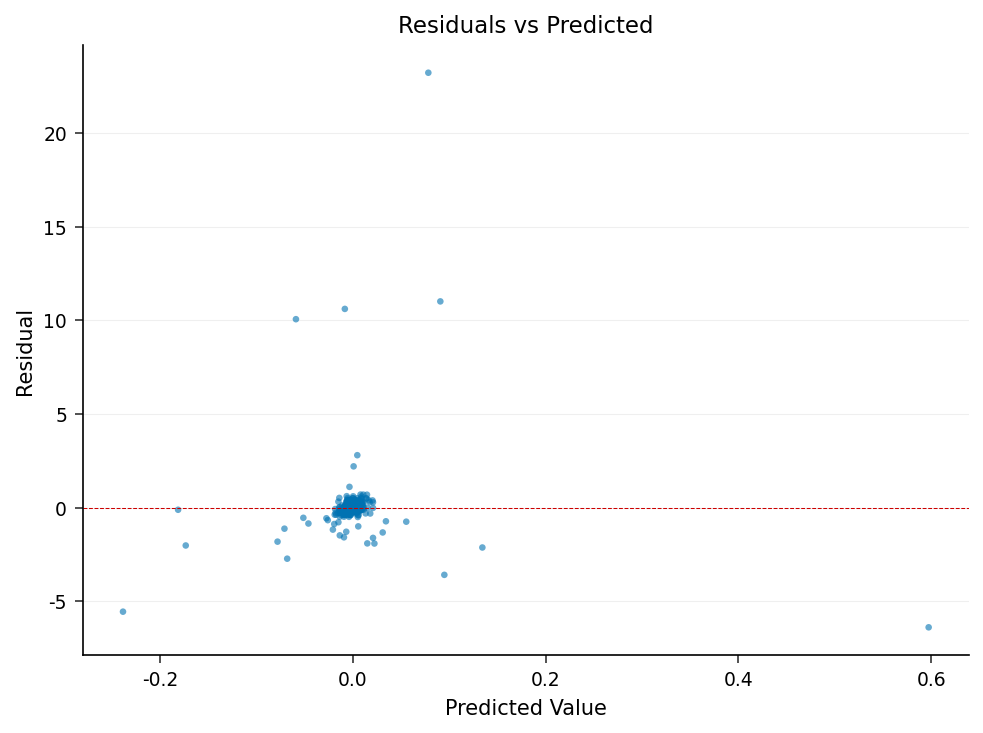

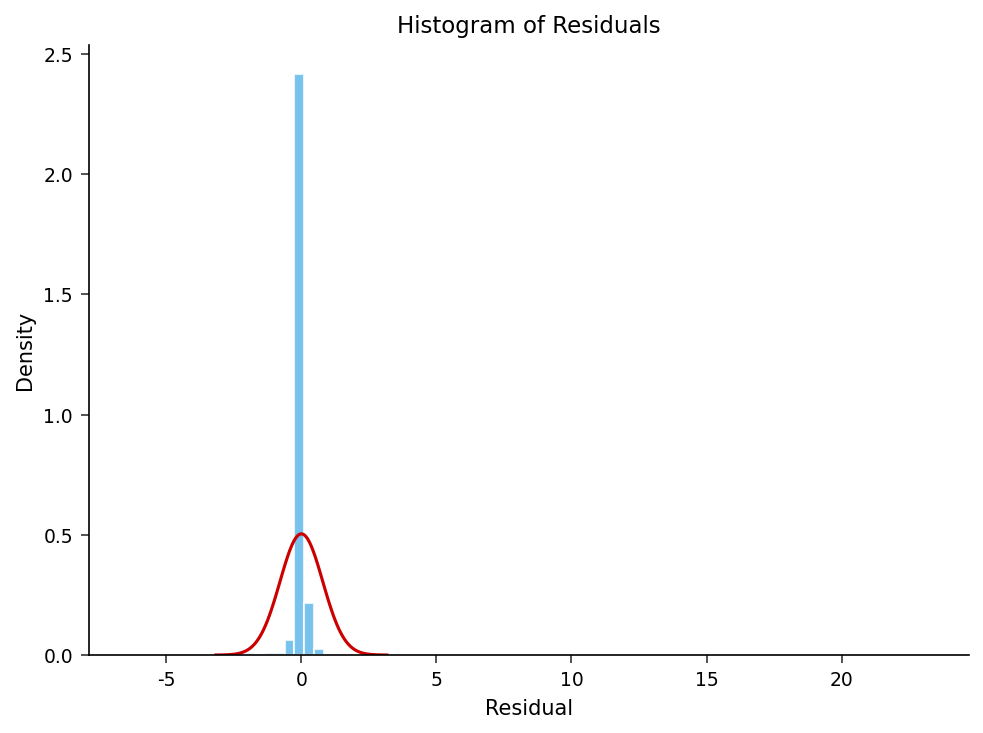

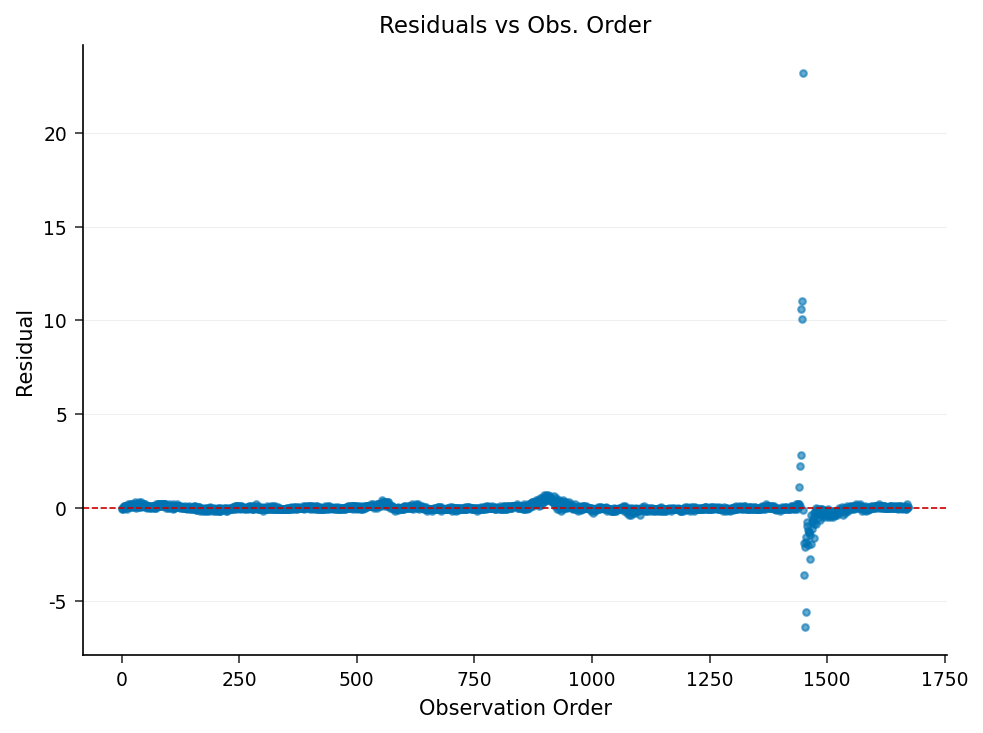

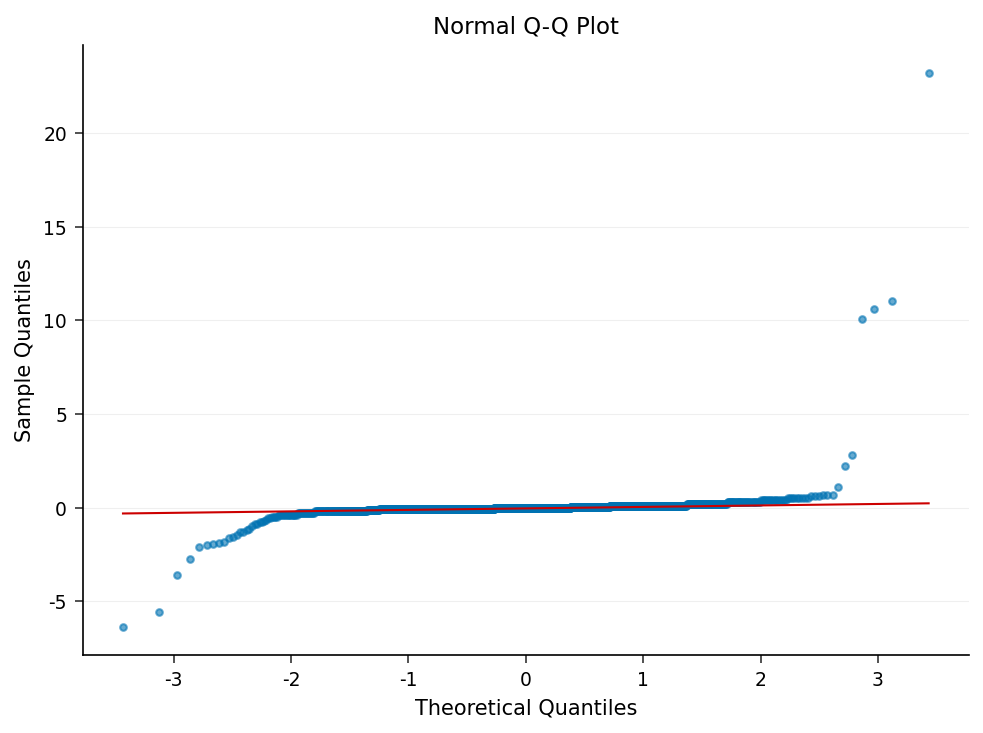

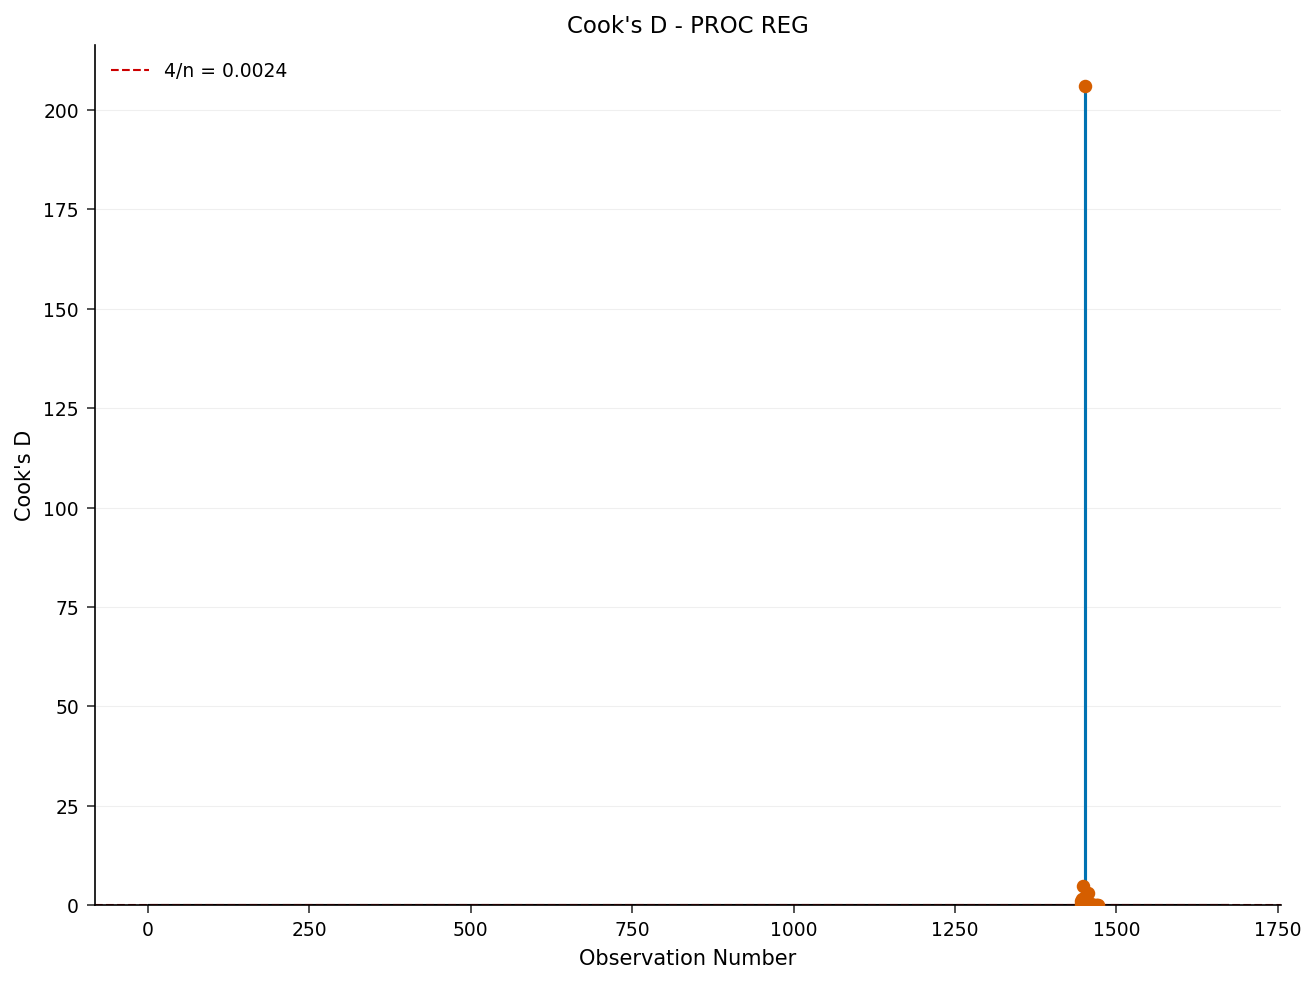

In [4]:
proc reg data=stacked outest="star_fit.csv";    model d_rate = own_lag nbr_lag / noint;run;

## Reading the Fit

The pooled regression stacks **1,672 observations** -- 418 monthly changes across four states -- and returns two coefficients:

- **`own_lag`** $= \phi_{10} = 0.043$ (SE 0.046, $p = 0.35$). A month's change in a state's unemployment carries only a faint echo into the next month.
- **`nbr_lag`** $= \phi_{11} = -0.038$ (SE 0.056, $p = 0.49$). When a state's neighbors moved last month, the state edges *slightly* the other way -- a hint of local, offsetting shocks rather than a wave sweeping the region.

Neither coefficient is statistically distinguishable from zero, and the model's $R^2$ is **0.0006**. Month-to-month changes in these rates sit close to white noise: there is little linear structure, temporal or spatial, to exploit at this frequency. That is a finding, not a failure -- it tells you the monthly regional signal is faint.

The diagnostic panels tell the rest of the story. The **Q-Q plot** shows heavy tails, and the **Cook's D** panel flags a single enormously influential observation, far above the $4/n$ reference line. That point is **April 2020**, when Nevada's rate leapt to 30.5% and California's to 16.1% as the pandemic shuttered tourism and services -- a shock no space-time smoothing was going to anticipate.

Run the same two-parameter model on **annual** data, where regional labor markets share slow, common cycles, and both coefficients typically turn strongly positive: spatial diffusion dominates at that scale. STAR reads whatever structure the series and its frequency actually contain -- strong regional spillover in one setting, a faint and outlier-dominated monthly signal here -- from the same two numbers and the same map.

### Key Takeaways

- STAR(1;1) compresses a full vector autoregression into two numbers and a fixed neighbor map, so it scales to many locations where a free VAR cannot.
- On monthly differenced unemployment, both the own-lag and spatial coefficients are small and insignificant -- honest evidence that the monthly regional signal is weak.
- Always read the diagnostics: here a single pandemic month carries outsized influence, a caution the point estimates alone would hide.